Train: 25,996 hàng (2022–2024)
Test : 4,345 hàng (2025)

Đang huấn luyện Random Forest...
✅ Hoàn thành!

Anomaly threshold (AQI): 272.5
Số điểm anomaly AQI: 280


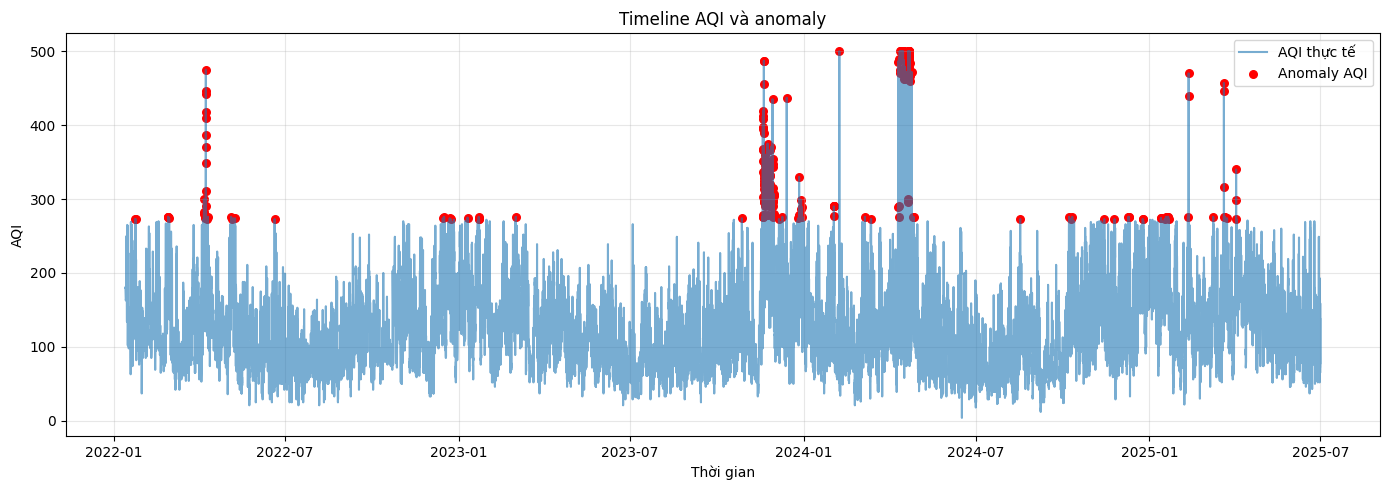


Anomaly theo mùa:
season_name  count
       Xuân    142
        Thu     86
       Đông     50
         Hè      2

Anomaly theo giờ:
 hour  count
    0     14
    1     14
    2     10
    3     16
    4     12
    5     18
    6     18
    7     17
    8     17
    9     16
   10     12
   11      7
   12      6
   13      4
   14      5
   15      5
   16      4
   17      5
   18      7
   19     11
   20     13
   21     14
   22     18
   23     17

Tỷ lệ anomaly trên tổng dữ liệu: 0.92%


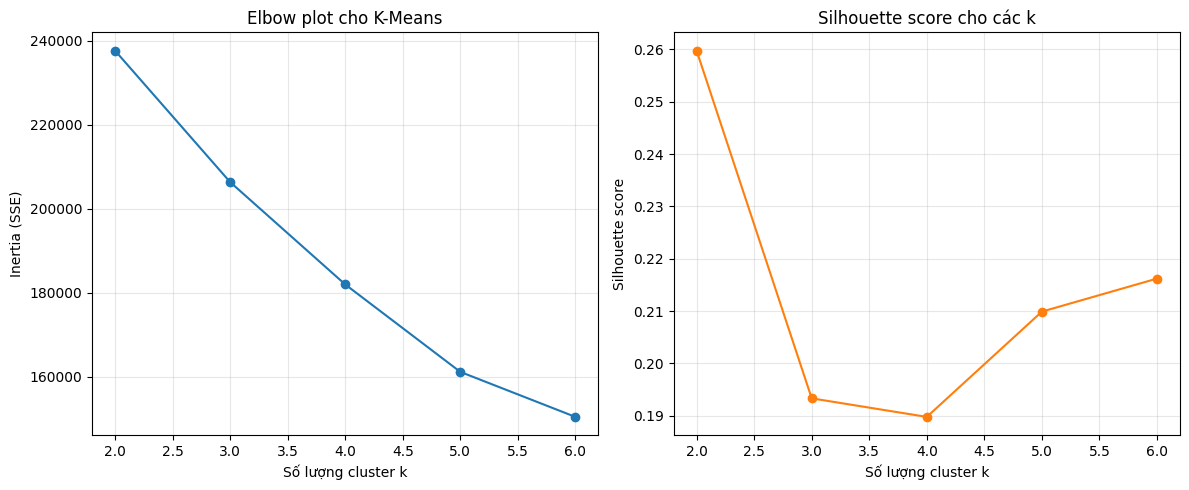


Best k theo silhouette score: 2

Cluster profile (centroids trên thang gốc):
            aqi   pm25    pm10      co    no2     o3    so2  temperature  \
cluster                                                                    
0         97.57  33.29   44.67  374.10  20.86  62.53  54.53        27.10   
1        182.11  89.46  124.14  363.95  42.78  46.54  81.31        19.96   

         relative_humidity  pressure  
cluster                               
0                    78.63   1007.12  
1                    75.30   1016.66  

Kích thước mỗi cluster:
cluster
0    20947
1     9394
Name: count, dtype: int64

Mô tả cluster theo mùa:
season_name    Hè   Thu  Xuân  Đông
cluster                            
0            7256  4769  6540  2382
1              88  1784  2295  5227

Mô tả cluster theo giờ:
hour      0    1    2    3    4    5    6    7    8    9   ...    14    15  \
cluster                                                    ...               
0        823  843  828  825  8

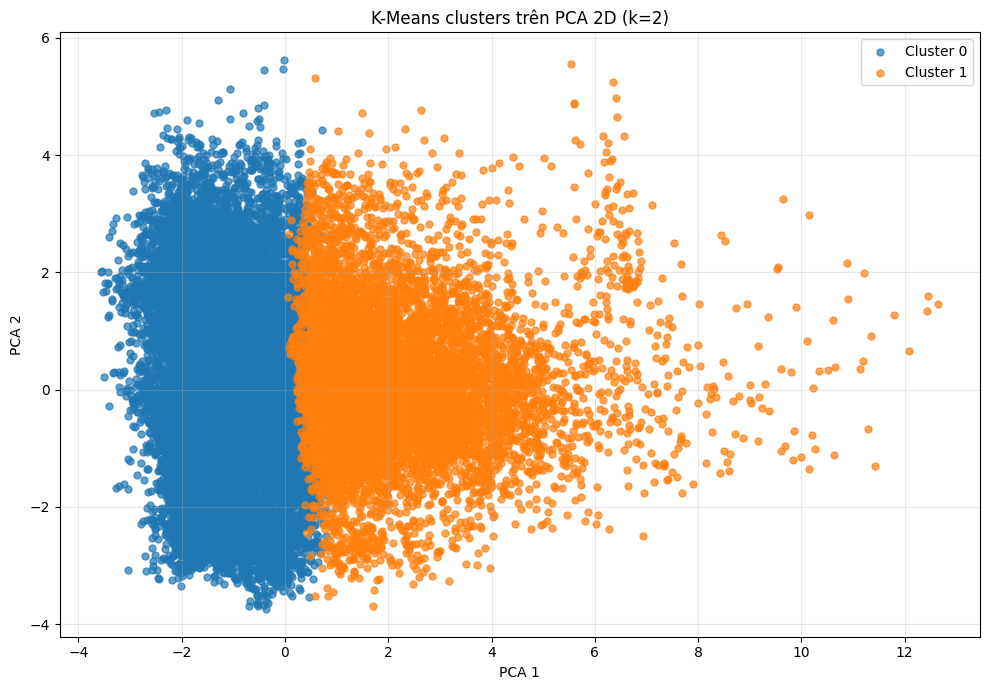


Top 10 feature quan trọng nhất theo SHAP:
    feature  mean_abs_shap
       pm25      37.890348
       pm10       9.577435
         o3       0.956063
         co       0.009938
        so2       0.008466
        no2       0.004242
       hour       0.004028
temperature       0.004016
   uv_index       0.002377
   pressure       0.001926


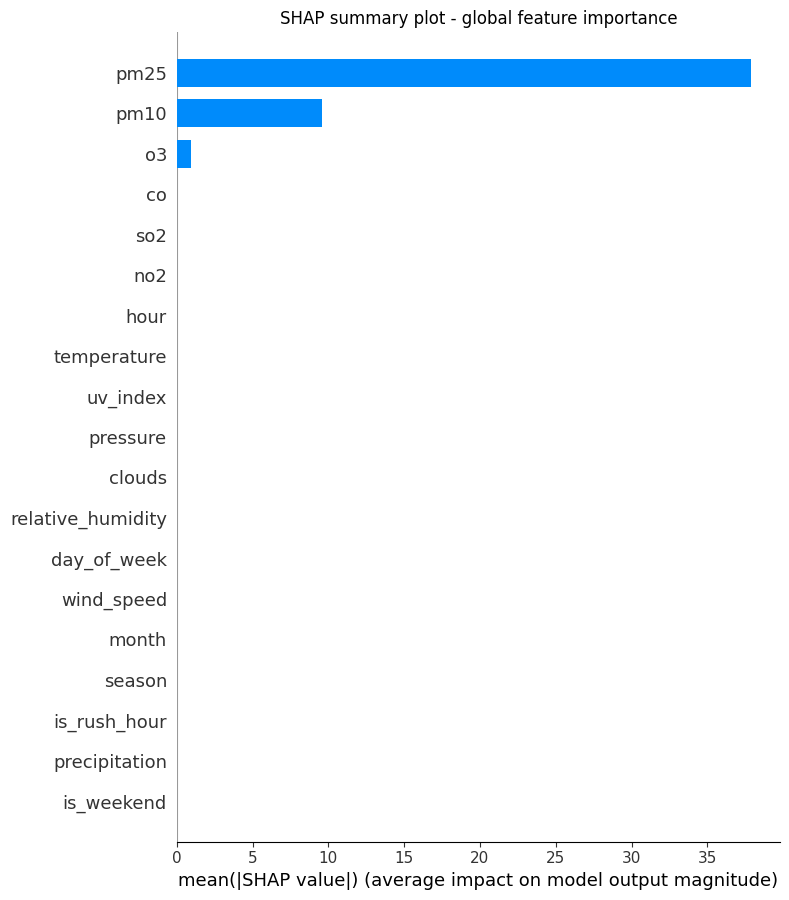

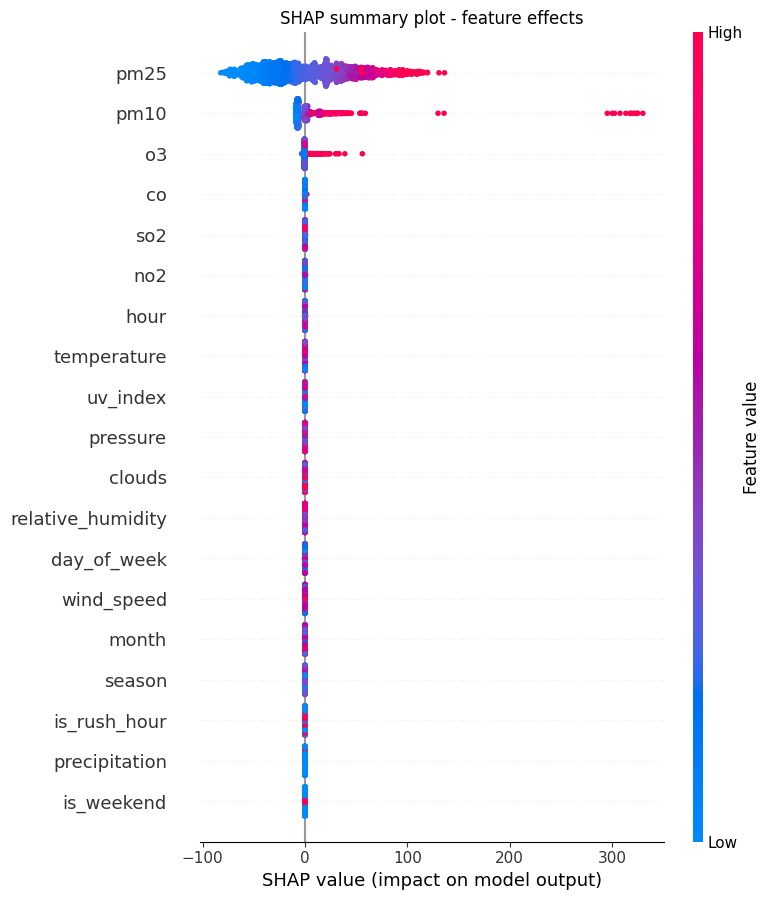


Waterfall explanation cho hàng dữ liệu gần AQI=300: thực tế=299.0, dự đoán=196.5, thời điểm=2025-04-02 22:00:00


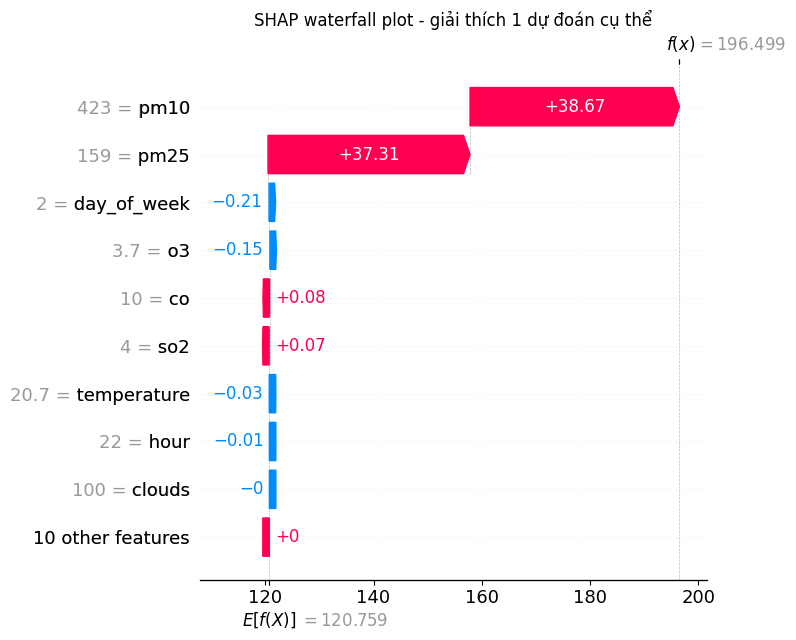

<Figure size 1000x700 with 0 Axes>

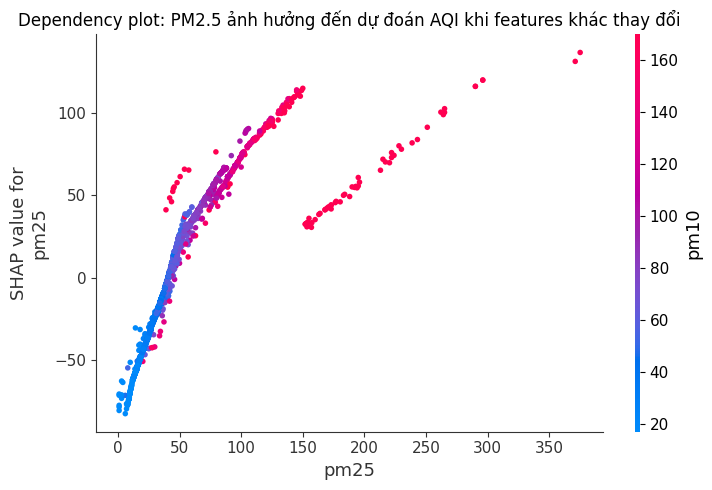


Kết luận: feature quan trọng nhất toàn cục là 'pm25' với mean |SHAP| = 37.8903.
Các feature khác có ảnh hưởng lớn gồm: pm25, pm10, o3, co, so2


In [5]:
import pandas as pd
import numpy as np
import warnings
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════
# 1. ĐỌC DỮ LIỆU & TRAIN MODEL
# ══════════════════════════════════════════════════════
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
except Exception:
    df = pd.read_csv('./hanoi_aqi_cleaned.csv')

SEASON_MAP = {0: 'Đông', 1: 'Xuân', 2: 'Hè', 3: 'Thu'}
df.columns = df.columns.str.strip().str.lower()
df['local_time'] = pd.to_datetime(df['local_time'], errors='coerce')
df['season_name'] = df['season'].map(SEASON_MAP)
df['hour'] = pd.to_numeric(df['hour'], errors='coerce').astype('Int64')
df['month'] = pd.to_numeric(df['month'], errors='coerce').astype('Int64')
df['day_of_week'] = pd.to_numeric(df['day_of_week'], errors='coerce').astype('Int64')
df['aqi'] = pd.to_numeric(df['aqi'], errors='coerce')

FEATURES = [
    'co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
    'clouds', 'precipitation', 'pressure',
    'relative_humidity', 'temperature', 'uv_index', 'wind_speed',
    'month', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'season'
]
TARGET = 'aqi'

train = df[df['year'] < 2025].copy()
test = df[df['year'] == 2025].copy()
X_train = train[FEATURES]
y_train = train[TARGET]

print(f"Train: {len(train):,} hàng (2022–2024)")
print(f"Test : {len(test):,} hàng (2025)")

rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
print("\nĐang huấn luyện Random Forest...")
rf_model.fit(X_train, y_train)
print("✅ Hoàn thành!")

# ══════════════════════════════════════════════════════
# 2. PHÁT HIỆN ANOMALY THEO AQI
# ══════════════════════════════════════════════════════

df = df.sort_values('local_time').reset_index(drop=True)
q1, q3 = df['aqi'].quantile([0.25, 0.75])
iqr = q3 - q1
anomaly_threshold = q3 + 1.5 * iqr
anomalies = df[df['aqi'] > anomaly_threshold].copy()
print(f"\nAnomaly threshold (AQI): {anomaly_threshold:.1f}")
print(f"Số điểm anomaly AQI: {len(anomalies):,}")

plt.figure(figsize=(14, 5))
plt.plot(df['local_time'], df['aqi'], label='AQI thực tế', color='tab:blue', alpha=0.6)
plt.scatter(anomalies['local_time'], anomalies['aqi'], color='red', label='Anomaly AQI', s=30)
plt.title('Timeline AQI và anomaly')
plt.xlabel('Thời gian')
plt.ylabel('AQI')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

anomaly_by_season = anomalies['season_name'].value_counts().rename_axis('season_name').reset_index(name='count')
anomaly_by_hour = anomalies['hour'].value_counts().sort_index().rename_axis('hour').reset_index(name='count')

print('\nAnomaly theo mùa:')
print(anomaly_by_season.to_string(index=False))
print('\nAnomaly theo giờ:')
print(anomaly_by_hour.to_string(index=False))

anomaly_rate = len(anomalies) / len(df) * 100
print(f"\nTỷ lệ anomaly trên tổng dữ liệu: {anomaly_rate:.2f}%")

# ══════════════════════════════════════════════════════
# 3. CLUSTER ANALYSIS & PCA VISUALIZATION
# ══════════════════════════════════════════════════════

cluster_features = [
    'aqi', 'pm25', 'pm10', 'co', 'no2', 'o3', 'so2',
    'temperature', 'relative_humidity', 'pressure'
]
cluster_df = df[cluster_features].dropna().copy()
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

inertia = []
silhouette_scores = []
ks = list(range(2, 7))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ks, inertia, marker='o')
plt.title('Elbow plot cho K-Means')
plt.xlabel('Số lượng cluster k')
plt.ylabel('Inertia (SSE)')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(ks, silhouette_scores, marker='o', color='tab:orange')
plt.title('Silhouette score cho các k')
plt.xlabel('Số lượng cluster k')
plt.ylabel('Silhouette score')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_k = ks[int(np.argmax(silhouette_scores))]
print(f"\nBest k theo silhouette score: {best_k}")

k_opt = best_k
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster)
cluster_profile = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=cluster_features
)
cluster_profile.index.name = 'cluster'
print('\nCluster profile (centroids trên thang gốc):')
print(cluster_profile.round(2))

clustered_df = cluster_df.copy()
clustered_df['cluster'] = cluster_labels
clustered_df['season_name'] = df.loc[clustered_df.index, 'season_name'].values
clustered_df['hour'] = df.loc[clustered_df.index, 'hour'].values

print('\nKích thước mỗi cluster:')
print(clustered_df['cluster'].value_counts().sort_index())

print('\nMô tả cluster theo mùa:')
print(clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0))

print('\nMô tả cluster theo giờ:')
print(clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0))

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
plt.figure(figsize=(10, 7))
palette = sns.color_palette('tab10', n_colors=k_opt)
for cluster_id in sorted(clustered_df['cluster'].unique()):
    mask = clustered_df['cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=25, alpha=0.7, label=f'Cluster {cluster_id}', color=palette[cluster_id])
plt.title(f'K-Means clusters trên PCA 2D (k={k_opt})')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════
# 4. SHAP EXPLAINABILITY
# ══════════════════════════════════════════════════════

X_train_numeric = X_train.astype(float)
shap_sample = X_train_numeric.sample(n=min(2000, len(X_train_numeric)), random_state=42)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(shap_sample)

feature_importance = pd.DataFrame({
    'feature': shap_sample.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('\nTop 10 feature quan trọng nhất theo SHAP:')
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False)
plt.title('SHAP summary plot - global feature importance')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title('SHAP summary plot - feature effects')
plt.tight_layout()
plt.show()

if len(test) > 0:
    candidate_idx = (test['aqi'] - 300).abs().idxmin()
    example = test.loc[candidate_idx]
    example_x = example[FEATURES].to_frame().T.astype(float)
    prediction = rf_model.predict(example_x)[0]
    shap_example = explainer.shap_values(example_x)

    print(f"\nWaterfall explanation cho hàng dữ liệu gần AQI=300: thực tế={example['aqi']}, dự đoán={prediction:.1f}, thời điểm={example['local_time']}")
    plt.figure(figsize=(10, 6))
    single_shap = shap_example[0][0] if isinstance(shap_example, list) else shap_example[0]
    base_value = explainer.expected_value[0] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
    shap.plots.waterfall(shap.Explanation(values=single_shap, base_values=base_value, data=example_x.iloc[0], feature_names=example_x.columns), show=False)
    plt.title('SHAP waterfall plot - giải thích 1 dự đoán cụ thể')
    plt.tight_layout()
    plt.show()
else:
    print('\nKhông tìm thấy dữ liệu test để hiển thị waterfall plot.')

plt.figure(figsize=(10, 7))
shap.dependence_plot('pm25', shap_values, shap_sample, feature_names=shap_sample.columns, show=False)
plt.title('Dependency plot: PM2.5 ảnh hưởng đến dự đoán AQI khi features khác thay đổi')
plt.tight_layout()
plt.show()

most_important = feature_importance.iloc[0]
print(f"\nKết luận: feature quan trọng nhất toàn cục là '{most_important['feature']}' với mean |SHAP| = {most_important['mean_abs_shap']:.4f}.")
print('Các feature khác có ảnh hưởng lớn gồm:', ', '.join(feature_importance.head(5)['feature'].tolist()))